# Research

In [1]:
%matplotlib inline

from data.data_manager import DataManager
from strategies.sma_crossover import SMACrossover
from analytics.plotting import plot_candles

### Create data manager and plot

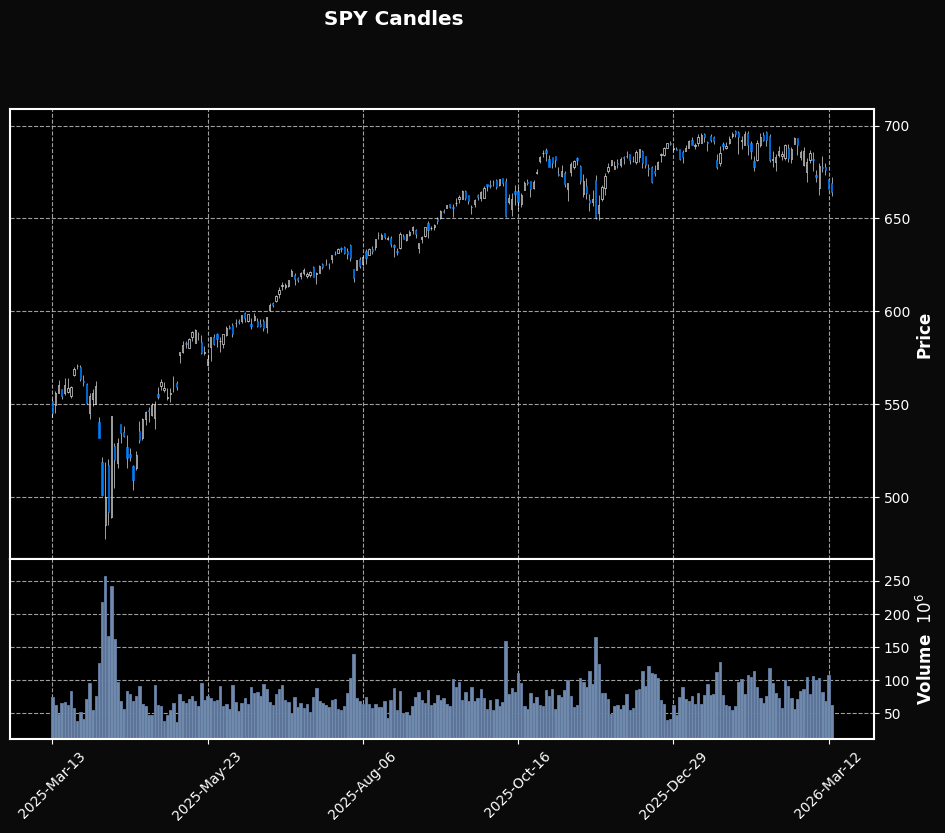

In [2]:
dm = DataManager("SPY", interval="1d", period="1y")

# Plot a single ticker

plot_candles(dm=dm, ticker="SPY")

### How raw data looks like

In [3]:
# Add SMA 20 and 50
dm.add_sma(20)
dm.add_sma(50)

print(dm.indicators["SPY"].tail())
print()
print(dm.data.tail())

                SMA_20      SMA_50
Date                              
2026-03-09  685.304001  687.856196
2026-03-10  684.465500  687.592196
2026-03-11  683.676001  687.312596
2026-03-12  682.381000  686.876797
2026-03-13  681.523499  686.418997

Price            Close        High         Low        Open     Volume
Date                                                                 
2026-03-09  678.270020  679.919983  662.390015  666.390015  102667700
2026-03-10  677.179993  683.359985  674.760010  677.719971   81505300
2026-03-11  676.330017  680.080017  673.340027  677.580017   68441700
2026-03-12  666.059998  671.650024  665.869995  671.159973  108493000
2026-03-13  664.119995  672.335022  662.080017  669.270020   62577361


# Backtesting

In [4]:
from strategies import sma_crossover
from data.data_manager import DataManager
from backtester import Backtester
from risk import base_risk
from sizing import base_size
from analytics.plotting import plot_candles

Backtest complete!
{'AAPL': {'entry_date': Timestamp('2026-03-13 18:38:00+0000', tz='UTC'), 'entry_price': np.float64(251.42999267578125), 'size': np.float64(38.178312088830936), 'direction': np.int64(1)}}
[{'asset': 'AAPL', 'entry_date': Timestamp('2026-03-05 15:46:00+0000', tz='UTC'), 'exit_date': Timestamp('2026-03-05 16:23:00+0000', tz='UTC'), 'entry_price': np.float64(260.04998779296875), 'exit_price': np.float64(260.489990234375), 'pnl': np.float64(16.919917787365755)}, {'asset': 'AAPL', 'entry_date': Timestamp('2026-03-05 16:34:00+0000', tz='UTC'), 'exit_date': Timestamp('2026-03-05 17:09:00+0000', tz='UTC'), 'entry_price': np.float64(260.6300048828125), 'exit_price': np.float64(260.4750061035156), 'pnl': np.float64(-5.957143577040172)}, {'asset': 'AAPL', 'entry_date': Timestamp('2026-03-05 18:13:00+0000', tz='UTC'), 'exit_date': Timestamp('2026-03-05 18:37:00+0000', tz='UTC'), 'entry_price': np.float64(259.3900146484375), 'exit_price': np.float64(258.69000244140625), 'pnl': np.

/home/charlie/github/Quant_research/.venv/lib64/python3.13/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


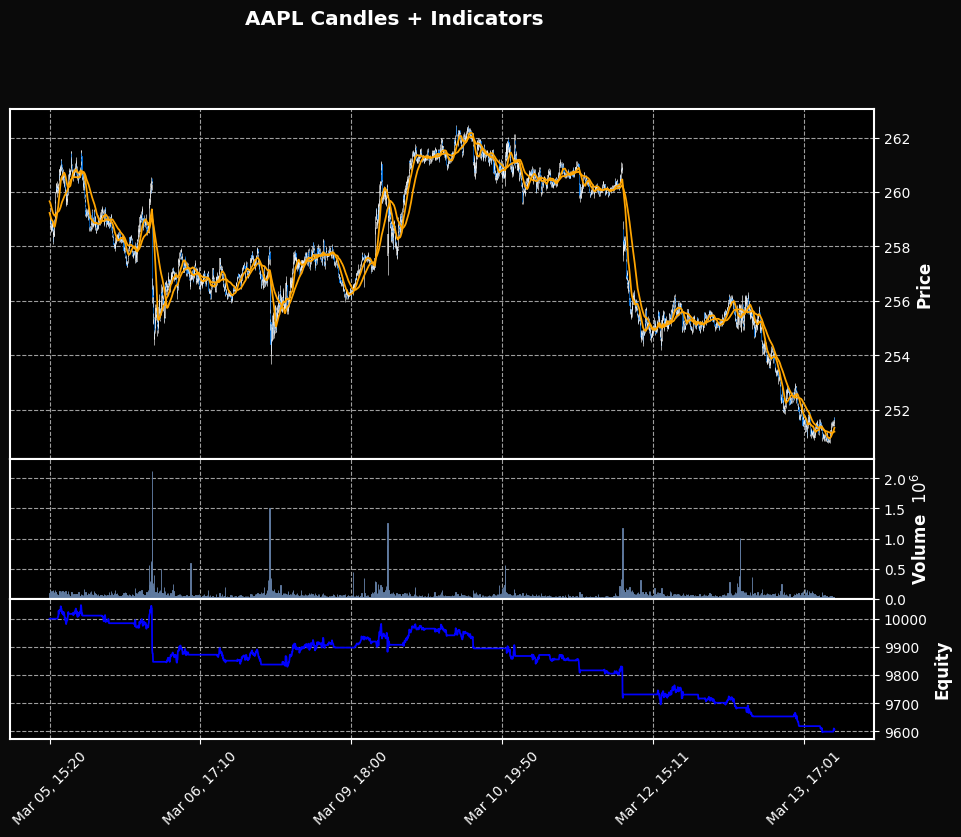

In [5]:
# 1. Load SPY data
dm = DataManager(ticker="AAPL", interval="1m", period="7d")

# 2. Initialize strategy
strategy = sma_crossover.SMACrossover(dm=dm, short_window=20, long_window=50)

# 3. Initialize risk and sizing objects
risk_manager = base_risk.StopLossTakeProfit(stop_loss=0.05, take_profit=0.10)
position_sizer = base_size.PositionSizer()  # assuming a get_size(cash, price) method

# 4. Initialize backtester
backtester = Backtester(
    data_manager=dm,
    strategy=strategy,
    risk=risk_manager,
    sizer=position_sizer,
    initial_capital=10000
)

# 5. Run backtest
equity_curve = backtester.run()

print("Backtest complete!")
print(backtester.positions)
print(backtester.trades)

print(equity_curve.head())
print(equity_curve.tail())
print(equity_curve.isna().sum())
print(len(backtester.trades))
print(backtester.trades)

# 6. Plot
plot_candles(dm=dm, ticker="AAPL", add_indicators=True, add_equity=equity_curve)